# Imports

In [1]:
import pandas as pd



import numpy as np



import os, glob



import matplotlib.pyplot as plt



import seaborn







from sklearn.linear_model import LinearRegression



from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error



import numpy as np



from sklearn.model_selection import train_test_split



from sklearn.metrics import accuracy_score



from sklearn.svm import SVC



from sklearn.datasets import load_iris







import tensorflow as tf

devs = tf.config.list_physical_devices('GPU')

for dev in devs:

    tf.config.experimental.set_memory_growth(dev, True)

    print(dev)



from tensorflow.keras import Sequential, optimizers, losses, layers







%matplotlib inline






















# Data Pre-processing

In [2]:
df_overview = pd.read_csv('/kaggle/input/rul-data/Battery_RUL.csv')

df_overview.head()

,Cycle_Index,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL
0,1.0,2595.30,1151.488500,3.670,3.211,5460.001,6755.01,10777.82,1112
1,2.0,7408.64,1172.512500,4.246,3.220,5508.992,6762.02,10500.35,1111
2,3.0,7393.76,1112.992000,4.249,3.224,5508.993,6762.02,10420.38,1110
3,4.0,7385.50,1080.320667,4.250,3.225,5502.016,6762.02,10322.81,1109
4,6.0,65022.75,29813.487000,4.290,3.398,5480.992,53213.54,56699.65,1107


In [3]:
def plot_dataframe_subplots(df, nrows, ncols, figsize=(30, 24)):

    """Plot a nrows x ncols grid of the df variables against the first column."""



    measurements = list(df.columns)

    plt.figure(figsize=figsize)



    # Use measurements[0] as the x-axis for all other variables

    x_values = df[measurements[0]]  # X-axis variable



    for idx, key in enumerate(measurements[1:], 1):  # Start from second measurement

        plt.subplot(nrows, ncols, idx)

        plt.plot(x_values, df[key])  # Plot other variables against measurements[0]

        plt.ylabel(key)

        plt.grid(True)

        plt.xlabel(measurements[0])  # X-axis is always measurements[0]



    plt.tight_layout()

    plt.show()


In [4]:
df_master = df_overview



print(list(df_master.columns.values))

['Cycle_Index', 'Discharge Time (s)', 'Decrement 3.6-3.4V (s)', 'Max. Voltage Dischar. (V)', 'Min. Voltage Charg. (V)', 'Time at 4.15V (s)', 'Time constant current (s)', 'Charging time (s)', 'RUL']


In [5]:
df_master.head()


,Cycle_Index,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL
0,1.0,2595.30,1151.488500,3.670,3.211,5460.001,6755.01,10777.82,1112
1,2.0,7408.64,1172.512500,4.246,3.220,5508.992,6762.02,10500.35,1111
2,3.0,7393.76,1112.992000,4.249,3.224,5508.993,6762.02,10420.38,1110
3,4.0,7385.50,1080.320667,4.250,3.225,5502.016,6762.02,10322.81,1109
4,6.0,65022.75,29813.487000,4.290,3.398,5480.992,53213.54,56699.65,1107


In [6]:
import pandas as pd



# get columns with NaN values



cols_with_nan = df_master.columns[df_master.isna().any()].tolist()







# print out columns with NaN values and how many NaN values they have



for col in cols_with_nan:



    print(col, "has", df_master[col].isna().sum(), "NaN values")

In [7]:
dftest = df_master

In [8]:
print(list(dftest.columns.values))

['Cycle_Index', 'Discharge Time (s)', 'Decrement 3.6-3.4V (s)', 'Max. Voltage Dischar. (V)', 'Min. Voltage Charg. (V)', 'Time at 4.15V (s)', 'Time constant current (s)', 'Charging time (s)', 'RUL']


In [9]:
import pandas as pd



# get columns with NaN values



cols_with_nan = dftest.columns[dftest.isna().any()].tolist()







# print out columns with NaN values and how many NaN values they have



for col in cols_with_nan:



    print(col, "has", dftest[col].isna().sum(), "NaN values")

In [10]:
dftest=dftest.dropna()

In [11]:
import pandas as pd



# get columns with NaN values



cols_with_nan = dftest.columns[dftest.isna().any()].tolist()







# print out columns with NaN values and how many NaN values they have



for col in cols_with_nan:



    print(col, "has", dftest[col].isna().sum(), "NaN values")

In [12]:
print(list(dftest.columns.values))

['Cycle_Index', 'Discharge Time (s)', 'Decrement 3.6-3.4V (s)', 'Max. Voltage Dischar. (V)', 'Min. Voltage Charg. (V)', 'Time at 4.15V (s)', 'Time constant current (s)', 'Charging time (s)', 'RUL']


In [13]:




def set_negative_plot_color():



    plt.figure(figsize=(30, 6), facecolor='black')



    ax = plt.axes()



    ax.set_facecolor("black")



    ax.spines['bottom'].set_color('white')



    ax.spines['top'].set_color('white')



    ax.spines['right'].set_color('white')



    ax.spines['left'].set_color('white')



    ax.tick_params(colors='white', which='both')



    plt.grid(True)







def regression_metrics(y_test, y_pred):



    # calculate errors



    mse = mean_squared_error(y_test, y_pred)



    rmse = mean_squared_error(y_test, y_pred, squared=False)



    eps = 1e-10 # a small value to avoid division by zero



    rmspe = np.sqrt(np.mean(np.square(((y_test - y_pred) / (y_test + eps)))))



    #rmspe = np.sqrt(np.mean(np.square(((y_test - y_pred)/y_test)), axis=0))



    mae = mean_absolute_error(y_test, y_pred)



    mape = mean_absolute_percentage_error(y_test, y_pred)



    # report error



    print(f'Mean Squared Error: {mse}')



    print(f'Root Mean Square Error: {rmse}')



    print(f'Root Mean Square Percentage Error: {rmspe}')



    print(f'Mean Absolute Error: {mae}')



    print(f'Mean Absolute Percentage Error: {mape}')











def plot_comparison(y_test, y_pred, xlabel, ylabel, dark_mode=False, figsize=(30, 6)):



    import matplotlib as mpl



    mpl.rcParams['agg.path.chunksize'] = 200



    mpl.rcParams['path.simplify_threshold'] = 0.5



    if dark_mode:



        plt.figure(figsize=figsize, facecolor='black')



        ax = plt.axes()



        ax.set_facecolor("black")



        ax.spines['bottom'].set_color('gray')



        ax.spines['top'].set_color('gray')



        ax.spines['right'].set_color('gray')



        ax.spines['left'].set_color('gray')



        ax.tick_params(colors='white', which='both')



        plt.plot(y_pred, color="yellow")



        plt.plot(y_test, color="white")



        plt.legend(['Predicted', 'Measured'])



        plt.xlabel(xlabel, color='white')



        plt.ylabel(ylabel, color='white')



    else:



        plt.figure(figsize=figsize)



        plt.plot(y_pred)



        plt.plot(y_test)



        plt.legend(['Predicted', 'Measured'])



        plt.xlabel(xlabel)



        plt.ylabel(ylabel)



    plt.grid(True)


In [14]:
X=dftest.drop(['RUL'],axis=1)



y= dftest['RUL']

In [15]:
df_x_y = dftest

In [16]:
print(list(df_x_y.columns.values))

['Cycle_Index', 'Discharge Time (s)', 'Decrement 3.6-3.4V (s)', 'Max. Voltage Dischar. (V)', 'Min. Voltage Charg. (V)', 'Time at 4.15V (s)', 'Time constant current (s)', 'Charging time (s)', 'RUL']


In [17]:
from sklearn.model_selection import train_test_split



X = df_x_y.drop(['RUL'], axis=1)



y = df_x_y[['RUL']]  # Close the square bracket



# Split the data into train and test sets with a ratio of 95:5



splitter = int(len(X) * 0.95)



X_train, X_test = X.values[:splitter], X.values[splitter:]



y_train, y_test = y.values[:splitter], y.values[splitter:]







# Split the train set into train and validation sets with a ratio of 90:10



splitter1 = int(len(X_train) * 0.9)



X_train, X_val = X_train[:splitter1], X_train[splitter1:]



y_train, y_val = y_train[:splitter1], y_train[splitter1:]







# Check the dataset sizes



print(X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape)


(12879, 8) (12879, 1) (1431, 8) (1431, 1) (754, 8) (754, 1)


# Custom Activation Function

In [18]:
def custom_activation(x):

    return tf.where(x >= 0, x,tf.tanh(x) +tf.atan(x) )

# Model 1 with relu

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 8, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 8, 32)     │        128 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 8, 32)     │        128 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 8, 32)     │        128 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 8, 32)     │          0 │ conv1d[0][0]      │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 8, 32)     │          0 │ conv1d_1[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 8, 32)     │          0 │ conv1d_2[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 8, 32)     │          0 │ activation[0][0], │
│                     │                   │            │ activation_1[0][… │
│                     │                   │            │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 32)        │      6,336 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │        528 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 8)         │        136 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │          9 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,393 (28.88 KB)

 Trainable params: 7,393 (28.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 201.6507 - mae: 201.5478 - val_loss: 38.4947 - val_mae: 38.3108 - learning_rate: 0.0100
Epoch 2/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 38.2090 - mae: 38.0085 - val_loss: 56.4760 - val_mae: 56.2586 - learning_rate: 0.0100
Epoch 3/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 53.8754 - mae: 53.6560 - val_loss: 42.0870 - val_mae: 41.8581 - learning_rate: 0.0100
Epoch 4/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 39.2486 - mae: 39.0148 - val_loss: 85.5558 - val_mae: 85.3126 - learning_rate: 0.0100
Epoch 5/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 53.6379 - mae: 53.3886 - val_loss: 51.3633 - val_mae: 51.1017 - learning_rate: 0.0100
Epoch 6/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 32.1135 - mae: 31.8507 - val_loss: 38.0835 - val_mae: 37.8109 - learning_rate: 0.0100
Epoch 7/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 37.6479 - mae: 37.3694 - val_loss: 13.5216 - val_mae: 1

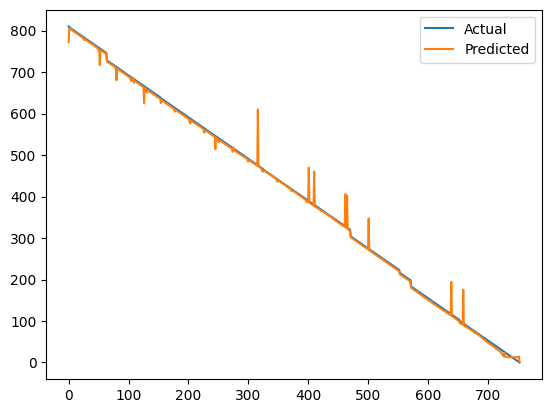

In [19]:
import os



from sklearn.preprocessing import StandardScaler



from tensorflow.keras.optimizers import Adam



from tensorflow.keras.layers import Conv1D, Input, Activation, Add, Concatenate, Dropout, Dense, GRU



from tensorflow.keras import Model



from tensorflow.keras.callbacks import EarlyStopping



from tensorflow.keras.regularizers import l2



import matplotlib.pyplot as plt







# ... (Code for loading data and other preprocessing steps) ...





# Create a StandardScaler object



scaler = StandardScaler()







# Normalize the training data



X_train_norm = scaler.fit_transform(X_train)



# Normalize the validation data using the same scaler object



X_val_norm = scaler.transform(X_val)



# Normalize the testing data using the same scaler object



X_test_norm = scaler.transform(X_test)







# Define a TCN block with dilations



def dilated_tcn_block(input_layer, nb_filters, kernel_size, dilation_rate):



    conv1 = Conv1D(filters=nb_filters, kernel_size=kernel_size, padding='causal', dilation_rate=dilation_rate)(input_layer)



    conv1 = Activation('relu')(conv1)



    return conv1







# Model definition



input_layer = Input(shape=(X_train_norm.shape[1], 1))



l2_strength = 0.001







# TCN block



tcn_blocks = []



for dilation_rate in [1, 2, 4]:



    tcn_block = dilated_tcn_block(input_layer, nb_filters=32, kernel_size=3, dilation_rate=dilation_rate)



    tcn_blocks.append(tcn_block)







# Merge TCN blocks



merged = Add()(tcn_blocks)







# GRU layer with regularization and dropout



gru_layer = GRU(32, activation='relu', return_sequences=False,



                kernel_regularizer=l2(l2_strength), recurrent_regularizer=l2(l2_strength), bias_regularizer=l2(l2_strength))(merged)







# Dense layers



dense1 = Dense(16, activation='relu', kernel_regularizer=l2(l2_strength), bias_regularizer=l2(l2_strength))(gru_layer)



dense2 = Dense(8, activation='relu', kernel_regularizer=l2(l2_strength), bias_regularizer=l2(l2_strength))(dense1)







# Output layer



output_layer = Dense(1, activation='linear', kernel_regularizer=l2(l2_strength), bias_regularizer=l2(l2_strength))(dense2)







# Combine the models



combined_model1 = Model(inputs=input_layer, outputs=output_layer)







# Compile the model with early stopping



opt = Adam(learning_rate=0.01)



combined_model1.compile(optimizer=opt, loss='mae', metrics=['mae'])



early_stopping = EarlyStopping(monitor='val_loss', patience=15)

lronplat = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=5)



combined_model1.summary()



 # Train the model



history = combined_model1.fit(X_train_norm, y_train, epochs=100, verbose=1,



                             batch_size=64,



                             validation_data=(X_val_norm, y_val),



                             callbacks=[early_stopping, lronplat])







# Evaluate the model on the test set



y_pred_combined = combined_model1.predict(X_test_norm)



regression_metrics(y_test, y_pred_combined)



# Plot the comparison between the predicted and actual values



plt.plot(y_test, label='Actual')



plt.plot(y_pred_combined, label='Predicted')



plt.legend()



plt.show()

# Model 1 with tanh


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 8, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 8, 32)     │        128 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 8, 32)     │        128 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 8, 32)     │        128 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 8, 32)     │          0 │ conv1d_3[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 8, 32)     │          0 │ conv1d_4[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 8, 32)     │          0 │ conv1d_5[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 8, 32)     │          0 │ activation_3[0][… │
│                     │                   │            │ activation_4[0][… │
│                     │                   │            │ activation_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 32)        │      6,336 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 32)        │          0 │ gru_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 16)        │        528 │ activation_6[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 16)        │          0 │ dense_3[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 8)         │        136 │ activation_7[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 8)         │          0 │ dense_4[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │          9 │ activation_8[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,393 (28.88 KB)

 Trainable params: 7,393 (28.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 549.4956 - mae: 549.3962 - val_loss: 597.5593 - val_mae: 597.4717 - learning_rate: 0.0100
Epoch 2/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 534.1246 - mae: 533.9868 - val_loss: 581.3856 - val_mae: 581.1641 - learning_rate: 0.0100
Epoch 3/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 513.7513 - mae: 513.4924 - val_loss: 566.4733 - val_mae: 566.0770 - learning_rate: 0.0100
Epoch 4/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 492.8162 - mae: 492.3622 - val_loss: 552.6093 - val_mae: 551.9639 - learning_rate: 0.0100
Epoch 5/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 478.2879 - mae: 477.5693 - val_loss: 539.5049 - val_mae: 538.5494 - learning_rate: 0.0100
Epoch 6/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 463.9321 - mae: 462.8886 - val_loss: 527.0621 - val_mae: 525.7391 - learning_rate: 0.0100
Epoch 7/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 458.1920 - mae: 456.7677 - val_lo

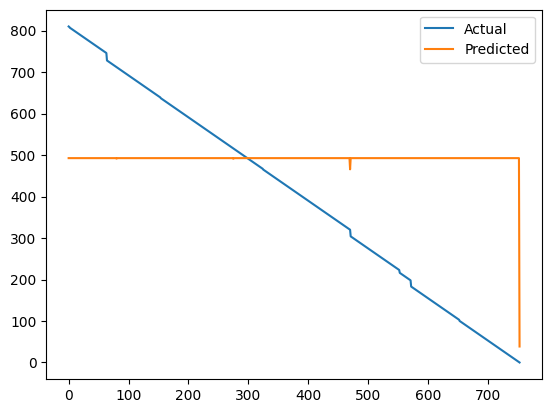

In [20]:
import os

import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.layers import Conv1D, Input, Activation, Add, Dropout, Dense, GRU

from tensorflow.keras import Model

from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.regularizers import l2



# Assuming X_train, X_val, X_test, y_train, y_val, y_test are defined



# Create a StandardScaler object

scaler = StandardScaler()



# Normalize the training, validation, and testing data

X_train_norm = scaler.fit_transform(X_train)

X_val_norm = scaler.transform(X_val)

X_test_norm = scaler.transform(X_test)



# Define a TCN block with dilations

def dilated_tcn_block(input_layer, nb_filters, kernel_size, dilation_rate):

    conv1 = Conv1D(filters=nb_filters, kernel_size=kernel_size, padding='causal', dilation_rate=dilation_rate)(input_layer)

    conv1 = Activation('tanh')(conv1)  # Replace P_Talu with tanh

    return conv1



# Model definition

input_layer = Input(shape=(X_train_norm.shape[1], 1))

l2_strength = 0.001



# TCN block

tcn_blocks = []

for dilation_rate in [1, 2, 4]:

    tcn_block = dilated_tcn_block(input_layer, nb_filters=32, kernel_size=3, dilation_rate=dilation_rate)

    tcn_blocks.append(tcn_block)



# Merge TCN blocks

merged = Add()(tcn_blocks)



# GRU layer with regularization and dropout

gru_layer = GRU(32, return_sequences=False,

                kernel_regularizer=l2(l2_strength), recurrent_regularizer=l2(l2_strength), bias_regularizer=l2(l2_strength))(merged)

gru_layer = Activation('tanh')(gru_layer)  # Replace P_Talu with tanh



# Dense layers

dense1 = Dense(16, kernel_regularizer=l2(l2_strength), bias_regularizer=l2(l2_strength))(gru_layer)

dense1 = Activation('tanh')(dense1)  # Replace P_Talu with tanh



dense2 = Dense(8, kernel_regularizer=l2(l2_strength), bias_regularizer=l2(l2_strength))(dense1)

dense2 = Activation('tanh')(dense2)  # Replace P_Talu with tanh



# Output layer

output_layer = Dense(1, activation='linear', kernel_regularizer=l2(l2_strength), bias_regularizer=l2(l2_strength))(dense2)



# Combine the models

combined_model1 = Model(inputs=input_layer, outputs=output_layer)



combined_model1.summary()



# Compile the model with early stopping

opt = Adam(learning_rate=0.01)

combined_model1.compile(optimizer=opt, loss='mae', metrics=['mae'])



early_stopping = EarlyStopping(monitor='val_loss', patience=15)

lronplat = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=3)



# Train the model

history = combined_model1.fit(X_train_norm, y_train, epochs=100, verbose=1,

                              batch_size=64,

                              validation_data=(X_val_norm, y_val),

                              callbacks=[early_stopping, lronplat])



# Evaluate the model on the test set

y_pred_combined = combined_model1.predict(X_test_norm)



# Define regression_metrics function as needed

regression_metrics(y_test, y_pred_combined)



# Plot the comparison between the predicted and actual values

plt.plot(y_test, label='Actual')

plt.plot(y_pred_combined, label='Predicted')

plt.legend()

plt.show()


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 8, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 8, 32)     │        128 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 8, 32)     │        128 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 8, 32)     │        128 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 8, 32)     │          0 │ conv1d_6[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 8, 32)     │          0 │ conv1d_7[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 8, 32)     │          0 │ conv1d_8[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 8, 32)     │          0 │ activation_9[0][… │
│                     │                   │            │ activation_10[0]… │
│                     │                   │            │ activation_11[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_2 (GRU)         │ (None, 32)        │      6,336 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 16)        │        528 │ gru_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 8)         │        136 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │          9 │ dense_7[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,393 (28.88 KB)

 Trainable params: 7,393 (28.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 212.6094 - mae: 212.4217 - val_loss: 39.9614 - val_mae: 39.7001 - learning_rate: 0.0100
Epoch 2/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 32.5827 - mae: 32.3094 - val_loss: 13.9093 - val_mae: 13.6132 - learning_rate: 0.0100
Epoch 3/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 29.8467 - mae: 29.5341 - val_loss: 34.3658 - val_mae: 34.0354 - learning_rate: 0.0100
Epoch 4/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 22.3844 - mae: 22.0454 - val_loss: 19.4931 - val_mae: 19.1288 - learning_rate: 0.0100
Epoch 5/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 18.1161 - mae: 17.7445 - val_loss: 26.3661 - val_mae: 25.9477 - learning_rate: 0.0100
Epoch 6/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 8.4167 - mae: 7.9977 - val_loss: 6.9488 - val_mae: 6.5282 - learning_rate: 1.0000e-03
Epoch 7/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5.6551 - mae: 5.2347 - val_loss: 7.9507 - val_mae: 7.5

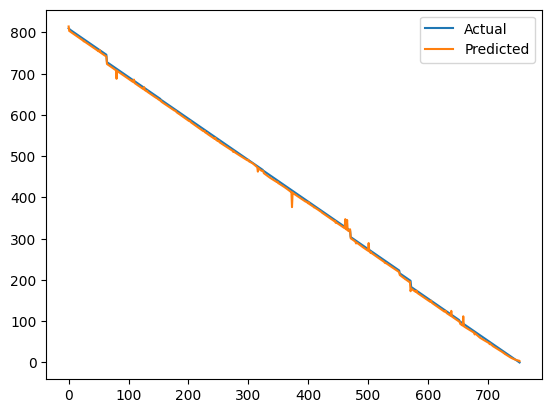

In [21]:
import os



from sklearn.preprocessing import StandardScaler



from tensorflow.keras.optimizers import Adam



from tensorflow.keras.layers import Conv1D, Input, Activation, Add, Concatenate, Dropout, Dense, GRU



from tensorflow.keras import Model



from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau



from tensorflow.keras.regularizers import l2



import matplotlib.pyplot as plt







# ... (Code for loading data and other preprocessing steps) ...







# Create a StandardScaler object



scaler = StandardScaler()







# Normalize the training data



X_train_norm = scaler.fit_transform(X_train)



# Normalize the validation data using the same scaler object



X_val_norm = scaler.transform(X_val)



# Normalize the testing data using the same scaler object



X_test_norm = scaler.transform(X_test)







# Define a TCN block with dilations



def dilated_tcn_block(input_layer, nb_filters, kernel_size, dilation_rate):



    conv1 = Conv1D(filters=nb_filters, kernel_size=kernel_size, padding='causal', dilation_rate=dilation_rate)(input_layer)



    conv1 = Activation(custom_activation)(conv1)



    return conv1







# Model definition



input_layer = Input(shape=(X_train_norm.shape[1], 1))



l2_strength = 0.001







# TCN block



tcn_blocks = []



for dilation_rate in [1, 2, 4]:



    tcn_block = dilated_tcn_block(input_layer, nb_filters=32, kernel_size=3, dilation_rate=dilation_rate)



    tcn_blocks.append(tcn_block)







# Merge TCN blocks



merged = Add()(tcn_blocks)







# GRU layer with regularization and dropout



gru_layer = GRU(32, activation=custom_activation, return_sequences=False,



                kernel_regularizer=l2(l2_strength), recurrent_regularizer=l2(l2_strength), bias_regularizer=l2(l2_strength))(merged)







# Dense layers



dense1 = Dense(16, activation=custom_activation, kernel_regularizer=l2(l2_strength), bias_regularizer=l2(l2_strength))(gru_layer)



dense2 = Dense(8, activation=custom_activation, kernel_regularizer=l2(l2_strength), bias_regularizer=l2(l2_strength))(dense1)







# Output layer



output_layer = Dense(1, activation='linear', kernel_regularizer=l2(l2_strength), bias_regularizer=l2(l2_strength))(dense2)







# Combine the models



combined_model2 = Model(inputs=input_layer, outputs=output_layer)



# combined_model.summary()







# Compile the model with early stopping



opt = Adam(learning_rate=0.01)



combined_model2.compile(optimizer=opt, loss='mae', metrics=['mae'])



early_stopping = EarlyStopping(monitor='val_loss', patience=25)



combined_model2.summary()

# Train the model



history = combined_model2.fit(X_train_norm, y_train, epochs=100, verbose=1,



                             batch_size=64,



                             validation_data=(X_val_norm, y_val),



                             callbacks=[early_stopping, lronplat])







# Evaluate the model on the test set



y_pred_combined = combined_model2.predict(X_test_norm)



regression_metrics(y_test, y_pred_combined)



# Plot the comparison between the predicted and actual values



plt.plot(y_test, label='Actual')



plt.plot(y_pred_combined, label='Predicted')



plt.legend()



plt.show()


# Model with gelu

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 8, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 8, 32)     │        128 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 8, 32)     │        128 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 8, 32)     │        128 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 8, 32)     │          0 │ conv1d_9[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_13       │ (None, 8, 32)     │          0 │ conv1d_10[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 8, 32)     │          0 │ conv1d_11[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 8, 32)     │          0 │ activation_12[0]… │
│                     │                   │            │ activation_13[0]… │
│                     │                   │            │ activation_14[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_3 (GRU)         │ (None, 32)        │      6,336 │ add_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 32)        │          0 │ gru_3[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 16)        │        528 │ activation_15[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_16       │ (None, 16)        │          0 │ dense_9[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 8)         │        136 │ activation_16[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_17       │ (None, 8)         │          0 │ dense_10[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1)         │          9 │ activation_17[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,393 (28.88 KB)

 Trainable params: 7,393 (28.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 384.4751 - mae: 384.1880 - val_loss: 13.4697 - val_mae: 12.6491 - learning_rate: 0.0100
Epoch 2/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 16.0294 - mae: 15.2142 - val_loss: 12.4292 - val_mae: 11.6196 - learning_rate: 0.0100
Epoch 3/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 13.3589 - mae: 12.5369 - val_loss: 17.2483 - val_mae: 16.4142 - learning_rate: 0.0100
Epoch 4/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 12.6296 - mae: 11.7937 - val_loss: 12.9711 - val_mae: 12.1363 - learning_rate: 0.0100
Epoch 5/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 10.9376 - mae: 10.0970 - val_loss: 8.9931 - val_mae: 8.1281 - learning_rate: 0.0100
Epoch 6/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 10.0579 - mae: 9.1909 - val_loss: 5.9602 - val_mae: 5.0962 - learning_rate: 0.0100
Epoch 7/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 10.5761 - mae: 9.7007 - val_loss: 14.4871 - val_mae: 13.598

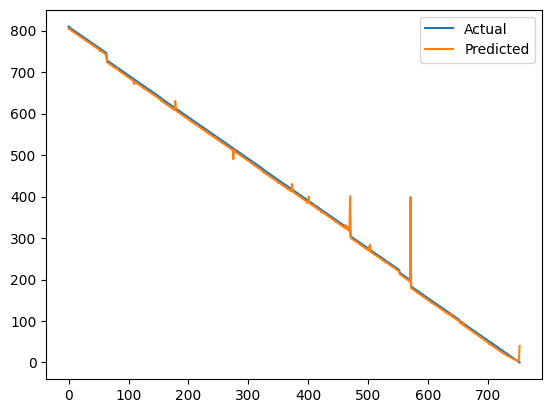

In [22]:
import os

import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.layers import Conv1D, Input, Activation, Add, Dropout, Dense, GRU

from tensorflow.keras import Model

from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.regularizers import l2

import tensorflow as tf



# Assuming X_train, X_val, X_test, y_train, y_val, y_test are defined



# Create a StandardScaler object

scaler = StandardScaler()



# Normalize the training, validation, and testing data

X_train_norm = scaler.fit_transform(X_train)

X_val_norm = scaler.transform(X_val)

X_test_norm = scaler.transform(X_test)



# Define a TCN block with dilations

def dilated_tcn_block(input_layer, nb_filters, kernel_size, dilation_rate):

    conv1 = Conv1D(filters=nb_filters, kernel_size=kernel_size, padding='causal', dilation_rate=dilation_rate)(input_layer)

    conv1 = Activation('gelu')(conv1)  # Replace tanh with GELU

    return conv1



# Model definition

input_layer = Input(shape=(X_train_norm.shape[1], 1))

l2_strength = 0.001



# TCN block

tcn_blocks = []

for dilation_rate in [1, 2, 4]:

    tcn_block = dilated_tcn_block(input_layer, nb_filters=32, kernel_size=3, dilation_rate=dilation_rate)

    tcn_blocks.append(tcn_block)



# Merge TCN blocks

merged = Add()(tcn_blocks)



# GRU layer with regularization and dropout

gru_layer = GRU(32, return_sequences=False,

                kernel_regularizer=l2(l2_strength), recurrent_regularizer=l2(l2_strength), bias_regularizer=l2(l2_strength))(merged)

gru_layer = Activation('gelu')(gru_layer)  # Replace tanh with GELU



# Dense layers

dense1 = Dense(16, kernel_regularizer=l2(l2_strength), bias_regularizer=l2(l2_strength))(gru_layer)

dense1 = Activation('gelu')(dense1)  # Replace tanh with GELU



dense2 = Dense(8, kernel_regularizer=l2(l2_strength), bias_regularizer=l2(l2_strength))(dense1)

dense2 = Activation('gelu')(dense2)  # Replace tanh with GELU



# Output layer

output_layer = Dense(1, activation='linear', kernel_regularizer=l2(l2_strength), bias_regularizer=l2(l2_strength))(dense2)



# Combine the models

combined_model1 = Model(inputs=input_layer, outputs=output_layer)



combined_model1.summary()



# Compile the model with early stopping

opt = Adam(learning_rate=0.01)

combined_model1.compile(optimizer=opt, loss='mae', metrics=['mae'])



early_stopping = EarlyStopping(monitor='val_loss', patience=15)

lronplat = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=3)



# Train the model

history = combined_model1.fit(X_train_norm, y_train, epochs=100, verbose=1,

                              batch_size=64,

                              validation_data=(X_val_norm, y_val),

                              callbacks=[early_stopping, lronplat])



# Evaluate the model on the test set

y_pred_combined = combined_model1.predict(X_test_norm)



# Define regression_metrics function as needed

regression_metrics(y_test, y_pred_combined)



# Plot the comparison between the predicted and actual values

plt.plot(y_test, label='Actual')

plt.plot(y_pred_combined, label='Predicted')

plt.legend()

plt.show()


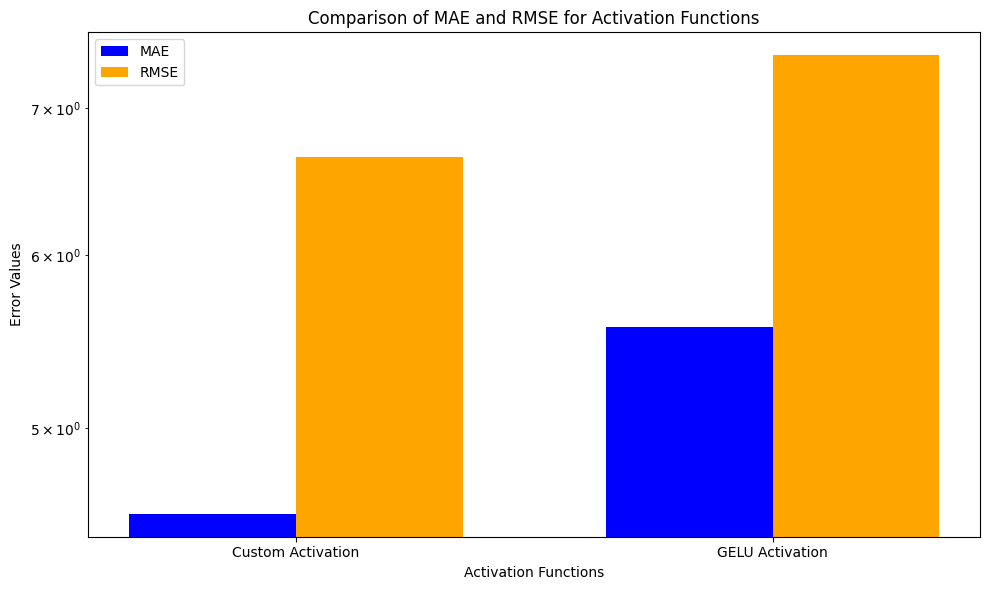

In [23]:
import matplotlib.pyplot as plt

import numpy as np



# Data for the activation functions

activation_functions = ['Custom Activation', 'GELU Activation']

mae_values = [4.57, 5.56]  # MAE values

rmse_values = [6.65, 7.40]  # RMSE values



# Bar width

bar_width = 0.35

x = np.arange(len(activation_functions))



# Creating the bar plots

plt.figure(figsize=(10, 6))



# MAE Bars

plt.bar(x - bar_width/2, mae_values, width=bar_width, label='MAE', color='blue')



# RMSE Bars

plt.bar(x + bar_width/2, rmse_values, width=bar_width, label='RMSE', color='orange')



# Adding titles and labels

plt.title('Comparison of MAE and RMSE for Activation Functions')

plt.xlabel('Activation Functions')

plt.ylabel('Error Values')

plt.xticks(x, activation_functions)

plt.yscale('log')  # Optional: use logarithmic scale for better visibility

plt.legend()

plt.grid(axis='y')



# Show the plot

plt.tight_layout()

plt.show()


# Model 4

# WITH RELU


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 8, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_16 (Conv1D)              │ (None, 8, 32)          │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 8, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 64)             │        12,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,985 (54.63 KB)

 Trainable params: 13,985 (54.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 218.6502 - mae: 218.4861 - val_loss: 96.3969 - val_mae: 96.1835 - learning_rate: 0.0100
Epoch 2/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 47.1818 - mae: 46.9556 - val_loss: 63.6638 - val_mae: 63.3869 - learning_rate: 0.0100
Epoch 3/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 56.3741 - mae: 56.0698 - val_loss: 15.6601 - val_mae: 15.2568 - learning_rate: 0.0100
Epoch 4/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 32.7989 - mae: 32.3693 - val_loss: 38.2339 - val_mae: 37.7597 - learning_rate: 0.0100
Epoch 5/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 27.3392 - mae: 26.8567 - val_loss: 23.4517 - val_mae: 22.9547 - learning_rate: 0.0100
Epoch 6/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 25.2650 - mae: 24.7623 - val_loss: 42.9461 - val_mae: 42.4223 - learning_rate: 0.0100
Epoch 7/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 29.0487 - mae: 28.5171 - val_loss: 26.1491 - val_mae: 

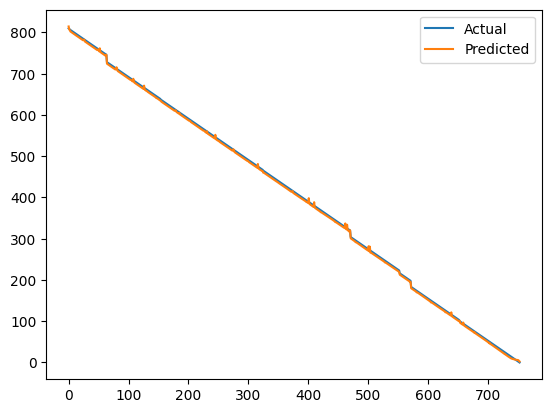

In [28]:
import os

from sklearn.preprocessing import StandardScaler

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.layers import Conv1D, Input, Activation, Add, Concatenate, Dropout, Dense, GRU, Bidirectional

from tensorflow.keras import Model

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from tensorflow.keras.regularizers import l2

import matplotlib.pyplot as plt



# Create a StandardScaler object

scaler = StandardScaler()



# Normalize the training data

X_train_norm = scaler.fit_transform(X_train)



# Normalize the validation data using the same scaler object

X_val_norm = scaler.transform(X_val)



# Normalize the testing data using the same scaler object

X_test_norm = scaler.transform(X_test)



# Model definition

input_layer = Input(shape=(X_train_norm.shape[1], 1))

l2_strength = 0.001



# CNN block

nb_filters = 32

kernel_size = 3

cnn_conv1 = Conv1D(filters=nb_filters, kernel_size=kernel_size, padding='causal')(input_layer)

cnn_activation1 = Activation('relu')(cnn_conv1)



# BiGRU layer with regularization and dropout

bigru_layer = Bidirectional(GRU(32, activation='relu', return_sequences=False,

                                kernel_regularizer=l2(l2_strength), recurrent_regularizer=l2(l2_strength),

                                bias_regularizer=l2(l2_strength)))(cnn_activation1)



# Dense layers

dense1 = Dense(16, activation='relu', kernel_regularizer=l2(l2_strength), bias_regularizer=l2(l2_strength))(bigru_layer)

dense2 = Dense(8, activation='relu', kernel_regularizer=l2(l2_strength), bias_regularizer=l2(l2_strength))(dense1)



# Output layer

output_layer = Dense(1, activation='linear', kernel_regularizer=l2(l2_strength), bias_regularizer=l2(l2_strength))(dense2)



# Combine the models

combined_model4 = Model(inputs=input_layer, outputs=output_layer)



combined_model4.summary()



# Compile the model with early stopping

opt = Adam(learning_rate=0.01)

combined_model4.compile(optimizer=opt, loss='mae', metrics=['mae'])



# Define early stopping and ReduceLROnPlateau callbacks

early_stopping = EarlyStopping(monitor='val_loss', patience=15)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=10, min_lr=1e-6)



# Train the model

history = combined_model4.fit(X_train_norm, y_train, epochs=100, verbose=1,

                              batch_size=64,

                              validation_data=(X_val_norm, y_val),

                              callbacks=[early_stopping, reduce_lr])



# Evaluate the model on the test set

y_pred_combined = combined_model4.predict(X_test_norm)



# Example of how you might define a regression metrics function

def regression_metrics(y_true, y_pred):

    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    print('MAE:', mean_absolute_error(y_true, y_pred))

    print('MSE:', mean_squared_error(y_true, y_pred))

    print('R2 Score:', r2_score(y_true, y_pred))



# Evaluate and print regression metrics

regression_metrics(y_test, y_pred_combined)



# Plot the comparison between the predicted and actual values

plt.plot(y_test, label='Actual')

plt.plot(y_pred_combined, label='Predicted')

plt.legend()

plt.show()


# WITH CUSTOM ACTIVATION


Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 8, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_17 (Conv1D)              │ (None, 8, 32)          │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 8, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 64)             │        12,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,985 (54.63 KB)

 Trainable params: 13,985 (54.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 543.8053 - mae: 543.6501 - val_loss: 580.9148 - val_mae: 580.7292
Epoch 2/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 507.8242 - mae: 507.5906 - val_loss: 552.2322 - val_mae: 551.8359
Epoch 3/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 480.6693 - mae: 480.2118 - val_loss: 526.5383 - val_mae: 525.8829
Epoch 4/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 454.7966 - mae: 454.0706 - val_loss: 503.3953 - val_mae: 502.4566
Epoch 5/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 430.4044 - mae: 429.3897 - val_loss: 482.5904 - val_mae: 481.3332
Epoch 6/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 402.3352 - mae: 400.9966 - val_loss: 480.3484 - val_mae: 478.5740
Epoch 7/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 391.3049 - mae: 388.7986 - val_loss: 446.7343 - val_mae: 444.0600
Epoch 8/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 374.3490 - mae: 371.6466 - val_loss: 430.5344 - v

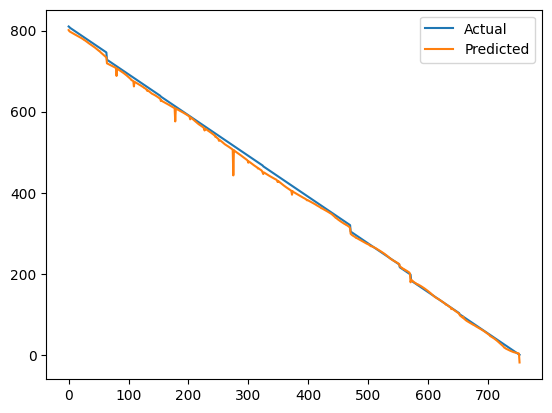

In [29]:
import os

import tensorflow as tf

from sklearn.preprocessing import StandardScaler

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.layers import Conv1D, Input, Activation, Add, Dense, GRU, Bidirectional

from tensorflow.keras import Model

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from tensorflow.keras.regularizers import l2

import matplotlib.pyplot as plt



# Define the custom activation function

def custom_activation(x):

    return tf.where(x >= 0, tf.atan(x), tf.tanh(x) + tf.atan(x))



# Loading and preprocessing data (assuming X_train, X_val, X_test, y_train, y_val, and y_test are already defined)

# Create a StandardScaler object

scaler = StandardScaler()



# Normalize the training data

X_train_norm = scaler.fit_transform(X_train)



# Normalize the validation data using the same scaler object

X_val_norm = scaler.transform(X_val)



# Normalize the testing data using the same scaler object

X_test_norm = scaler.transform(X_test)



# Model definition

input_layer = Input(shape=(X_train_norm.shape[1], 1))

l2_strength = 0.001



# CNN block with custom activation

nb_filters = 32

kernel_size = 3

cnn_conv1 = Conv1D(filters=nb_filters, kernel_size=kernel_size, padding='causal')(input_layer)

cnn_activation1 = Activation(custom_activation)(cnn_conv1)  # Use custom activation here



# BiGRU layer with regularization (No custom activation directly in GRU)

bigru_layer = Bidirectional(GRU(32, return_sequences=False,

                                kernel_regularizer=l2(l2_strength), recurrent_regularizer=l2(l2_strength),

                                bias_regularizer=l2(l2_strength)))(cnn_activation1)



# Apply custom activation on BiGRU output using Activation layer

bigru_activation = Activation(custom_activation)(bigru_layer)



# Dense layers with custom activation

dense1 = Dense(16, activation=custom_activation, kernel_regularizer=l2(l2_strength), bias_regularizer=l2(l2_strength))(bigru_activation)

dense2 = Dense(8, activation=custom_activation, kernel_regularizer=l2(l2_strength), bias_regularizer=l2(l2_strength))(dense1)



# Output layer (no activation function applied as this is a regression task)

output_layer = Dense(1, activation='linear', kernel_regularizer=l2(l2_strength), bias_regularizer=l2(l2_strength))(dense2)



# Combine the model

combined_model4 = Model(inputs=input_layer, outputs=output_layer)



# Print the model summary

combined_model4.summary()



# Compile the model with Adam optimizer and early stopping

opt = Adam(learning_rate=0.01)

combined_model4.compile(optimizer=opt, loss='mae', metrics=['mae'])



# Define early stopping

early_stopping = EarlyStopping(monitor='val_loss', patience=15)



# Train the model

history = combined_model4.fit(X_train_norm, y_train, epochs=100, verbose=1,

                              batch_size=64,

                              validation_data=(X_val_norm, y_val),

                              callbacks=[early_stopping])



# Evaluate the model on the test set

y_pred_combined = combined_model4.predict(X_test_norm)



# Example of how you might define a regression metrics function

def regression_metrics(y_true, y_pred):

    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    print('MAE:', mean_absolute_error(y_true, y_pred))

    print('MSE:', mean_squared_error(y_true, y_pred))

    print('R2 Score:', r2_score(y_true, y_pred))



# Evaluate and print regression metrics

regression_metrics(y_test, y_pred_combined)



# Plot the comparison between the predicted and actual values

plt.plot(y_test, label='Actual')

plt.plot(y_pred_combined, label='Predicted')

plt.legend()

plt.show()


# WITH TANH

Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 8, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_18 (Conv1D)              │ (None, 8, 32)          │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_25 (Activation)      │ (None, 8, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 64)             │        12,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_26 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,985 (54.63 KB)

 Trainable params: 13,985 (54.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 545.9698 - mae: 545.8488 - val_loss: 598.3730 - val_mae: 598.2934
Epoch 2/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 533.3168 - mae: 533.2137 - val_loss: 582.1724 - val_mae: 581.9771
Epoch 3/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 512.8870 - mae: 512.6498 - val_loss: 567.2222 - val_mae: 566.8414
Epoch 4/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 499.5540 - mae: 499.1151 - val_loss: 553.3356 - val_mae: 552.7060
Epoch 5/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 479.2753 - mae: 478.5732 - val_loss: 540.2143 - val_mae: 539.2753
Epoch 6/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 466.9877 - mae: 465.9631 - val_loss: 527.7314 - val_mae: 526.4288
Epoch 7/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 461.3220 - mae: 459.7911 - val_loss: 516.9762 - val_mae: 514.2679
Epoch 8/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 443.6155 - mae: 440.7277 - val_loss: 505.6348 - 

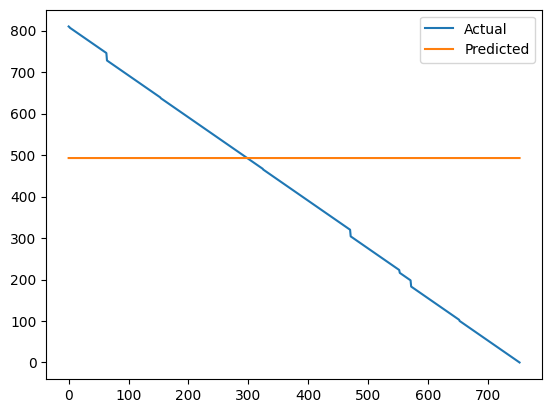

In [30]:
import os

import tensorflow as tf

from sklearn.preprocessing import StandardScaler

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.layers import Conv1D, Input, Activation, Add, Dense, GRU, Bidirectional

from tensorflow.keras import Model

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from tensorflow.keras.regularizers import l2

import matplotlib.pyplot as plt



# Loading and preprocessing data (assuming X_train, X_val, X_test, y_train, y_val, and y_test are already defined)

# Create a StandardScaler object

scaler = StandardScaler()



# Normalize the training data

X_train_norm = scaler.fit_transform(X_train)



# Normalize the validation data using the same scaler object

X_val_norm = scaler.transform(X_val)



# Normalize the testing data using the same scaler object

X_test_norm = scaler.transform(X_test)



# Model definition

input_layer = Input(shape=(X_train_norm.shape[1], 1))

l2_strength = 0.001



# CNN block with tanh activation

nb_filters = 32

kernel_size = 3

cnn_conv1 = Conv1D(filters=nb_filters, kernel_size=kernel_size, padding='causal')(input_layer)

cnn_activation1 = Activation('tanh')(cnn_conv1)  # Use tanh activation here



# BiGRU layer with regularization (No custom activation directly in GRU)

bigru_layer = Bidirectional(GRU(32, return_sequences=False,

                                kernel_regularizer=l2(l2_strength), recurrent_regularizer=l2(l2_strength),

                                bias_regularizer=l2(l2_strength)))(cnn_activation1)



# Apply tanh activation on BiGRU output using Activation layer

bigru_activation = Activation('tanh')(bigru_layer)



# Dense layers with tanh activation

dense1 = Dense(16, activation='tanh', kernel_regularizer=l2(l2_strength), bias_regularizer=l2(l2_strength))(bigru_activation)

dense2 = Dense(8, activation='tanh', kernel_regularizer=l2(l2_strength), bias_regularizer=l2(l2_strength))(dense1)



# Output layer (no activation function applied as this is a regression task)

output_layer = Dense(1, activation='linear', kernel_regularizer=l2(l2_strength), bias_regularizer=l2(l2_strength))(dense2)



# Combine the model

combined_model4 = Model(inputs=input_layer, outputs=output_layer)



# Print the model summary

combined_model4.summary()



# Compile the model with Adam optimizer and early stopping

opt = Adam(learning_rate=0.01)

combined_model4.compile(optimizer=opt, loss='mae', metrics=['mae'])



# Define early stopping

early_stopping = EarlyStopping(monitor='val_loss', patience=15)



# Train the model

history = combined_model4.fit(X_train_norm, y_train, epochs=100, verbose=1,

                              batch_size=64,

                              validation_data=(X_val_norm, y_val),

                              callbacks=[early_stopping])



# Evaluate the model on the test set

y_pred_combined = combined_model4.predict(X_test_norm)



# Example of how you might define a regression metrics function

def regression_metrics(y_true, y_pred):

    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    print('MAE:', mean_absolute_error(y_true, y_pred))

    print('MSE:', mean_squared_error(y_true, y_pred))

    print('R2 Score:', r2_score(y_true, y_pred))



# Evaluate and print regression metrics

regression_metrics(y_test, y_pred_combined)



# Plot the comparison between the predicted and actual values

plt.plot(y_test, label='Actual')

plt.plot(y_pred_combined, label='Predicted')

plt.legend()

plt.show()


# WITH GELU

Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 8, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_19 (Conv1D)              │ (None, 8, 32)          │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ (None, 8, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 64)             │        12,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_28 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,985 (54.63 KB)

 Trainable params: 13,985 (54.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 343.1811 - mae: 342.7949 - val_loss: 21.0316 - val_mae: 20.1906
Epoch 2/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 13.7728 - mae: 12.9125 - val_loss: 14.0854 - val_mae: 13.2311
Epoch 3/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 10.7933 - mae: 9.9409 - val_loss: 8.7384 - val_mae: 7.8953
Epoch 4/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 8.1420 - mae: 7.3023 - val_loss: 8.2051 - val_mae: 7.3721
Epoch 5/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 9.2559 - mae: 8.4234 - val_loss: 9.4292 - val_mae: 8.6011
Epoch 6/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 8.1803 - mae: 7.3566 - val_loss: 7.7358 - val_mae: 6.9276
Epoch 7/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 7.6586 - mae: 6.8529 - val_loss: 13.9654 - val_mae: 13.1619
Epoch 8/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 7.6108 - mae: 6.8102 - val_loss: 9.2172 - val_mae: 8.4187
Epoch 9/100
202/202 ━━━━━━━━━━━━━

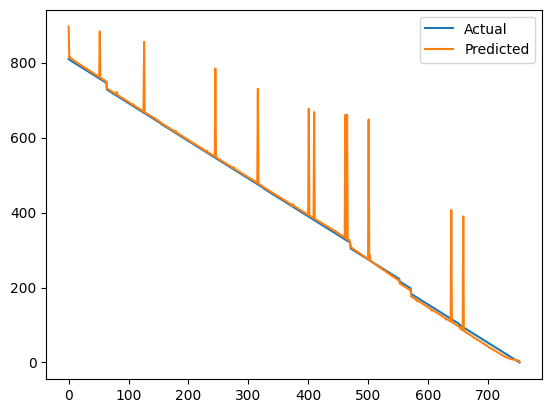

In [31]:
import os

import tensorflow as tf

from sklearn.preprocessing import StandardScaler

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.layers import Conv1D, Input, Activation, Add, Dense, GRU, Bidirectional

from tensorflow.keras import Model

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from tensorflow.keras.regularizers import l2

import matplotlib.pyplot as plt



# Loading and preprocessing data (assuming X_train, X_val, X_test, y_train, y_val, and y_test are already defined)

# Create a StandardScaler object

scaler = StandardScaler()



# Normalize the training data

X_train_norm = scaler.fit_transform(X_train)



# Normalize the validation data using the same scaler object

X_val_norm = scaler.transform(X_val)



# Normalize the testing data using the same scaler object

X_test_norm = scaler.transform(X_test)



# Model definition

input_layer = Input(shape=(X_train_norm.shape[1], 1))

l2_strength = 0.001



# CNN block with GELU activation

nb_filters = 32

kernel_size = 3

cnn_conv1 = Conv1D(filters=nb_filters, kernel_size=kernel_size, padding='causal')(input_layer)

cnn_activation1 = Activation('gelu')(cnn_conv1)  # Use GELU activation here



# BiGRU layer with regularization (No custom activation directly in GRU)

bigru_layer = Bidirectional(GRU(32, return_sequences=False,

                                kernel_regularizer=l2(l2_strength), recurrent_regularizer=l2(l2_strength),

                                bias_regularizer=l2(l2_strength)))(cnn_activation1)



# Apply GELU activation on BiGRU output using Activation layer

bigru_activation = Activation('gelu')(bigru_layer)



# Dense layers with GELU activation

dense1 = Dense(16, activation='gelu', kernel_regularizer=l2(l2_strength), bias_regularizer=l2(l2_strength))(bigru_activation)

dense2 = Dense(8, activation='gelu', kernel_regularizer=l2(l2_strength), bias_regularizer=l2(l2_strength))(dense1)



# Output layer (no activation function applied as this is a regression task)

output_layer = Dense(1, activation='linear', kernel_regularizer=l2(l2_strength), bias_regularizer=l2(l2_strength))(dense2)



# Combine the model

combined_model4 = Model(inputs=input_layer, outputs=output_layer)



# Print the model summary

combined_model4.summary()



# Compile the model with Adam optimizer and early stopping

opt = Adam(learning_rate=0.01)

combined_model4.compile(optimizer=opt, loss='mae', metrics=['mae'])



# Define early stopping

early_stopping = EarlyStopping(monitor='val_loss', patience=15)



# Train the model

history = combined_model4.fit(X_train_norm, y_train, epochs=100, verbose=1,

                              batch_size=64,

                              validation_data=(X_val_norm, y_val),

                              callbacks=[early_stopping])



# Evaluate the model on the test set

y_pred_combined = combined_model4.predict(X_test_norm)



# Example of how you might define a regression metrics function

def regression_metrics(y_true, y_pred):

    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    print('MAE:', mean_absolute_error(y_true, y_pred))

    print('MSE:', mean_squared_error(y_true, y_pred))

    print('R2 Score:', r2_score(y_true, y_pred))



# Evaluate and print regression metrics

regression_metrics(y_test, y_pred_combined)



# Plot the comparison between the predicted and actual values

plt.plot(y_test, label='Actual')

plt.plot(y_pred_combined, label='Predicted')

plt.legend()

plt.show()
